## 1e Trial By Trial plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
import os
import glob
import re
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle

In [2]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta

cycle4_1 = [2,4,1,3]
cycle4_2 = [3,4,2,1]
cycle4_3 = [1,2,3,4]
cycle4_4 = [3,1,4,2]
cycle4_5 = [1,2,4,3]
cycle4_6 = [4,3,2,1]

[2025-11-09 16:21:17,045][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [ ]:
animal = "eliot"
day = "20221022"

In [35]:
nwb_file_name = animal.lower() + day + '.nwb'

nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

print(nwb_copy_file_name)
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
print(session_interval)
session_name = session_interval[1]
            
q = {"nwb_file_name": nwb_copy_file_name,
     "epoch": session_name[:2],
    "proportion": 0.1,
     "delta_t_minus":5, "delta_t_plus":5,
     "max_flag":1}

df = ChangeofMindTheta().fetch1_dataframe(q)   

eliot20221020_.nwb
['02_Seq2Session1', '04_Seq2Session2', '06_Seq2Session3', '08_Seq2Session4', '10_Seq2Session5', '12_Seq2Session6']


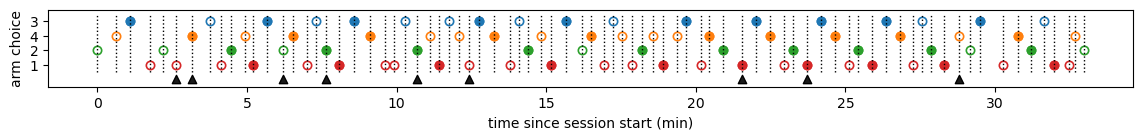

In [36]:
min_num = 0
max_num = 80

t0 = np.array(df.loc[min_num:max_num].timestamp_H)
t1 = np.array(df.loc[min_num:max_num].timestamp_O)
outers = df.loc[min_num:max_num].OuterWellIndex #outer arm choice
rewarded = df.loc[min_num:max_num].rewardNum == 2

illegal = df.loc[min_num:max_num].rewardNum == 0
com = df.loc[min_num:max_num].change_of_mind


# arange_type
seqn = cycle4_2

fig,axes=plt.subplots(1,1,sharex=True,figsize=(14,1))

ax = axes
for t in t1:
    ax.plot([t,t],[-0.5,3.5],'k:',linewidth=1,)
        
    # choices, rewards etc
for a in range(4): # arm 1-4
    a_trials=np.argwhere(outers==seqn[a]).ravel()
    trials_time = t1[a_trials]
    ax.scatter(trials_time,3-a*np.ones_like(a_trials),linewidths=1.2,edgecolors='C'+str(a),facecolor=[1,1,1])
            
    rewarded_a=np.argwhere(np.logical_and(outers==seqn[a],rewarded)).ravel();
    trials_time = t1[rewarded_a]
    ax.scatter(trials_time,3-a*np.ones_like(rewarded_a),edgecolors='C'+str(a),facecolor='C'+str(a),);
            
    #illegal_a=np.argwhere(np.logical_and(outers==seqn[a],illegal)).ravel();
    #ax.scatter(illegal_a,3-a*np.ones_like(illegal_a),edgecolors='C'+str(a),facecolor=[0.1,0.1,0.1]);

    com_a=np.argwhere(np.logical_and(outers==seqn[a],com)).ravel();
    trials_time = t1[com_a]
    ax.scatter(trials_time,np.ones_like(com_a)-2,edgecolors='k',marker='^',facecolor=[0.1,0.1,0.1]);
         
ax.set_yticks(np.arange(4))
ax.set_yticklabels(seqn[::-1])
ax.set_ylabel('arm choice')
ax.set_xlabel('time since session start (min)')
ax.set_ylim([-1.5,3.8])

xticks = np.arange(t1[0], t1[-1], 5*60)
ax.set_xticks(xticks);
ax.set_xticklabels([str(int(np.round(t/60))) for t in xticks - t0[0]]);
plt.savefig(f'choice_in_time_learning_{nwb_copy_file_name}_{session_name}.pdf',dpi=300,bbox_inches='tight')
#axes.set_title(data['date_session'][s]+' '+data['seq'][s],loc='left')
        
        